In [1]:
from datetime import datetime
import pandas as pd
import yfinance as yf
import requests
import zipfile
from io import BytesIO
import numpy as np
import json

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# A. Brent 가격이랑 관련된 것만 넣어서 baseline

In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

In [4]:
# ============================
# 1. Windowing Function
# ============================

def create_windows(df_scaled, df_original, target_col="brent_ret_5d", seq_len=30):
    """
    df_scaled  : 입력 피처들 (scaling된 데이터)
    df_original: 원본 데이터 (close값 + 원본 return 포함)
    target_col : 예측할 컬럼 (return)
    """
    X, y, close_today = [], [], []

    scaled_vals = df_scaled.values
    cols = df_scaled.columns.tolist()

    # 가격 복원용 close는 원본 사용
    original_close = df_original["brent_close"].values
    original_target = df_original[target_col].values   # ★ 원본 return 가져오기

    for i in range(len(df_scaled) - seq_len - 1):

        # 입력 시퀀스 (scaled)
        X.append(scaled_vals[i:i+seq_len])

        # target은 scaled 사용하면 절대 안됨!
        y.append(original_target[i+seq_len])

        # price 복원용 원본 close
        close_today.append(original_close[i+seq_len])

    return np.array(X), np.array(y), np.array(close_today)


# ============================
# 2. Dataset + Dataloader
# ============================

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# ============================
# 3. Bi-GRU Model
# ============================

class BiGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=1, dropout=0.1):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=True
        )
        self.fc = nn.Linear(hidden_dim * 2, 1)  # BiGRU -> 2 * hidden

    def forward(self, x):
        out, _ = self.gru(x)          # out: (batch, seq_len, hidden*2)
        last = out[:, -1, :]          # 마지막 시점
        return self.fc(last)


# ============================
# 4. Train Function
# ============================

def train_model(model, train_loader, val_loader, epochs=30, lr=1e-3):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0

        for X_batch, y_batch in train_loader:
            pred = model(X_batch)
            loss = criterion(pred, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_val, y_val in val_loader:
                pred = model(X_val)
                loss = criterion(pred, y_val)
                val_loss += loss.item()

        print(f"[Epoch {epoch:02d}] train={train_loss:.5f}, val={val_loss:.5f}")


# ============================
# 5. Predict & Price Restoration
# ============================

def predict_and_restore_price(model, X, close_today):
    model.eval()
    X_tensor = torch.tensor(X, dtype=torch.float32)
    with torch.no_grad():
        pred_ret = model(X_tensor).numpy().reshape(-1)

    # price 복원
    pred_price = close_today * (1 + pred_ret)
    return pred_ret, pred_price


# ============================
# 6. 시각화
# ============================


def plot_results(y_test, pred_ret, close_test, pred_price):
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # --- Return 시각화 ---
    axes[0].plot(y_test, label="Actual Return", linewidth=2)
    axes[0].plot(pred_ret, label="Predicted Return", linewidth=2)
    axes[0].set_title("Brent 1D Return Prediction")
    axes[0].legend()
    axes[0].grid(True)

    # --- Price 시각화 ---
    axes[1].plot(close_test, label="Actual Close Price", linewidth=2)
    axes[1].plot(pred_price, label="Predicted Close Price", linewidth=2)
    axes[1].set_title("Brent Close Price (Restored from Return)")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

def evaluate_predictions(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)

    # 방향성 정확도
    direction = np.mean(np.sign(y_true) == np.sign(y_pred))

    print("\n===== Evaluation =====")
    print(f"RMSE: {rmse:.6f}")
    print(f"MAE : {mae:.6f}")
    print(f"Direction Accuracy: {direction:.4f}")

    return rmse, mae, direction

# ============================
# 7. Full Pipeline
# ============================

def run_bigru_pipeline(df, seq_len=30, target_col="brent_ret_5d"):

    # return 컬럼 전체 제거 (leakage 방지)
    ret_cols = [c for c in df.columns if "ret_" in c and c != target_col]

    df_input = df.drop(columns=ret_cols + ["brent_close", "wti_close"], errors="ignore")


    # 2) 스케일링 (input only)
    scaler = StandardScaler()
    df_scaled = pd.DataFrame(
        scaler.fit_transform(df_input),
        index=df.index,
        columns=df_input.columns
    )

    # 3) window 생성 (y는 원본 return, close_today도 원본)
    X, y, close_today = create_windows(
        df_scaled,
        df_original=df,
        target_col=target_col,
        seq_len=seq_len
    )

    # ----- split -----
    train_size = int(len(X) * 0.7)
    val_size   = int(len(X) * 0.15)

    X_train, y_train = X[:train_size], y[:train_size]
    X_val, y_val     = X[train_size:train_size+val_size], y[train_size:train_size+val_size]
    X_test, y_test   = X[train_size+val_size:], y[train_size+val_size:]
    close_test       = close_today[train_size+val_size:]

    # ----- dataloader -----
    train_ds = TimeSeriesDataset(X_train, y_train)
    val_ds   = TimeSeriesDataset(X_val, y_val)

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=32)

    # ----- model -----
    input_dim = X.shape[2]
    model = BiGRU(input_dim=input_dim, hidden_dim=64, num_layers=1)

    # ----- train -----
    train_model(model, train_loader, val_loader, epochs=40, lr=1e-3)

    # ----- test prediction -----
    pred_ret, pred_price = predict_and_restore_price(model, X_test, close_test)

    # ----- evaluation -----
    rmse, mae, direction = evaluate_predictions(y_test, pred_ret)
    import joblib

    # ----- plot -----
    plot_results(y_test, pred_ret, close_test, pred_price)
    torch.save(model.state_dict(), "../ai/model_weight/bigru_brent_ret5d.pth")
    joblib.dump(scaler, "../ai/model_weight/scaler_brent_ret5d.pkl")

    return {
        "model": model,
        "metrics": {
            "rmse": rmse,
            "mae": mae,
            "direction_accuracy": direction
        },
        "prediction": {
            "y_test": y_test,
            "pred_ret": pred_ret,
            "pred_price": pred_price
        },
        "scaler": scaler,
        "train_windows": X_train,     
         "feature_names": df_input.columns.tolist()
    }


In [5]:
def make_brent_wti_features(start="2013-09-01", end=None, target_horizon=1):
    import yfinance as yf
    import pandas as pd

    brent = yf.download("BZ=F", start=start, end=end, auto_adjust=False, progress=False)
    wti   = yf.download("CL=F", start=start, end=end, auto_adjust=False, progress=False)

    brent = brent.rename(columns=str.lower)
    wti   = wti.rename(columns=str.lower)

    df = pd.DataFrame(index=brent.index)
    df["brent_close"] = brent["close"]
    df["wti_close"]   = wti["close"].reindex(df.index)

    # Spread
    df["brent_wti_spread"] = df["brent_close"] - df["wti_close"]

    # Returns (미래 정보 포함 가능성 있음 → 뒤에서 필터링)
    df["brent_ret_1d"]  = df["brent_close"].pct_change(1)
    df["brent_ret_5d"]  = df["brent_close"].pct_change(5)
    df["brent_ret_20d"] = df["brent_close"].pct_change(20)

    df["wti_ret_1d"]  = df["wti_close"].pct_change(1)
    df["wti_ret_5d"]  = df["wti_close"].pct_change(5)
    df["wti_ret_20d"] = df["wti_close"].pct_change(20)

    # Moving averages
    df["brent_ma_5"]  = df["brent_close"].rolling(5).mean()
    df["brent_ma_20"] = df["brent_close"].rolling(20).mean()
    df["brent_ma_60"] = df["brent_close"].rolling(60).mean()

    df["wti_ma_5"]  = df["wti_close"].rolling(5).mean()
    df["wti_ma_20"] = df["wti_close"].rolling(20).mean()
    df["wti_ma_60"] = df["wti_close"].rolling(60).mean()

    # Volatility proxies
    df["brent_vol_5d"] = df["brent_close"].pct_change().rolling(5).std()
    df["wti_vol_5d"]   = df["wti_close"].pct_change().rolling(5).std()

    df["high_low_range"] = (brent["high"] - brent["low"]) / brent["close"]

    if target_horizon == 1:
        # 1D 예측은 안전 → 그대로 두기
        pass

    elif target_horizon == 5:
        # 5D 예측 → 어떤 5D/20D return feature도 남아 있으면 안 됨
        drop_cols = [
            c for c in df.columns
            if (
                ("ret_5d" in c or "ret_20d" in c)
                and c != "brent_ret_5d"  # 타겟만 남기기
            )
        ]
        df = df.drop(columns=drop_cols)

    elif target_horizon == 20:
        # 20D 예측 → 5d/20d return 전부 제거 (타겟 제외)
        drop_cols = [
            c for c in df.columns
            if ("ret_5d" in c or "ret_20d" in c)
            and c != "brent_ret_20d"
        ]
        df = df.drop(columns=drop_cols)

    return df.dropna()


features = make_brent_wti_features(target_horizon=5)
features = features[features.index >= "2014-01-01"]
print(features.tail())


            brent_close  wti_close  brent_wti_spread  brent_ret_1d  \
Date                                                                 
2025-11-18    64.889999  60.740002          4.149998      0.010748   
2025-11-19    63.509998  59.439999          4.070000     -0.021267   
2025-11-20    63.380001  59.139999          4.240002     -0.002047   
2025-11-21    62.560001  58.060001          4.500000     -0.012938   
2025-11-24    61.410000  57.849998          3.560001     -0.018382   

            brent_ret_5d  wti_ret_1d  brent_ma_5  brent_ma_20  brent_ma_60  \
Date                                                                         
2025-11-18     -0.004144    0.013854   63.839999      64.3905    65.495833   
2025-11-19      0.012757   -0.021403   63.999998      64.4365    65.434000   
2025-11-20      0.005872   -0.005047   64.073999      64.3060    65.356166   
2025-11-21     -0.028421   -0.018262   63.707999      64.1370    65.255166   
2025-11-24     -0.043458   -0.003617   63

C:\Users\SKAX\AppData\Local\Temp\ipykernel_23332\4108742217.py:23: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["wti_ret_1d"]  = df["wti_close"].pct_change(1)
C:\Users\SKAX\AppData\Local\Temp\ipykernel_23332\4108742217.py:24: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["wti_ret_5d"]  = df["wti_close"].pct_change(5)
C:\Users\SKAX\AppData\Local\Temp\ipykernel_23332\4108742217.py:25: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_me

In [9]:
print(features.columns.tolist())


['brent_close', 'wti_close', 'brent_wti_spread', 'brent_ret_1d', 'brent_ret_5d', 'wti_ret_1d', 'brent_ma_5', 'brent_ma_20', 'brent_ma_60', 'wti_ma_5', 'wti_ma_20', 'wti_ma_60', 'brent_vol_5d', 'wti_vol_5d', 'high_low_range']


[Epoch 01] train=0.15941, val=0.02632
[Epoch 02] train=0.07443, val=0.02391
[Epoch 03] train=0.09570, val=0.01733
[Epoch 04] train=0.08928, val=0.01814
[Epoch 05] train=0.08132, val=0.02049
[Epoch 06] train=0.07304, val=0.02258
[Epoch 07] train=0.07671, val=0.02042
[Epoch 08] train=0.06598, val=0.01743
[Epoch 09] train=0.06881, val=0.01875
[Epoch 10] train=0.07018, val=0.02097
[Epoch 11] train=0.07018, val=0.01590
[Epoch 12] train=0.07285, val=0.02133
[Epoch 13] train=0.06302, val=0.01774
[Epoch 14] train=0.06761, val=0.01729
[Epoch 15] train=0.06744, val=0.01649
[Epoch 16] train=0.06608, val=0.01966
[Epoch 17] train=0.06609, val=0.03747
[Epoch 18] train=0.06976, val=0.01767
[Epoch 19] train=0.06485, val=0.01825
[Epoch 20] train=0.06508, val=0.01651
[Epoch 21] train=0.06419, val=0.01615
[Epoch 22] train=0.06000, val=0.01930
[Epoch 23] train=0.06076, val=0.02621
[Epoch 24] train=0.06196, val=0.01681
[Epoch 25] train=0.05905, val=0.02992
[Epoch 26] train=0.05897, val=0.03680
[Epoch 27] t

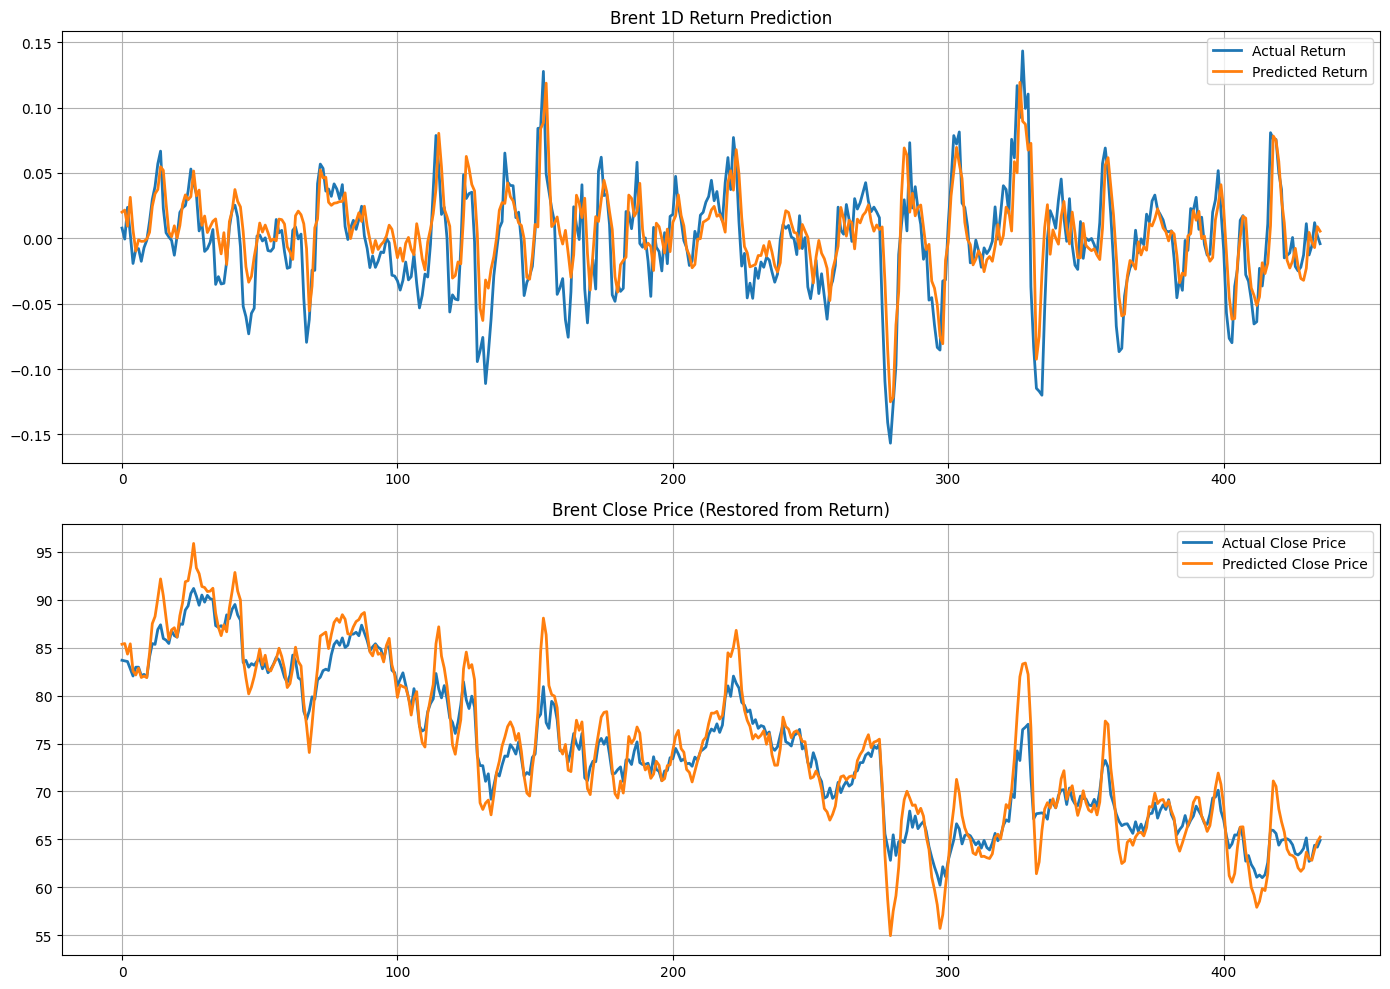

{'model': BiGRU(
   (gru): GRU(11, 64, batch_first=True, bidirectional=True)
   (fc): Linear(in_features=128, out_features=1, bias=True)
 ),
 'metrics': {'rmse': np.float64(0.026815708423554085),
  'mae': 0.020136369963010412,
  'direction_accuracy': np.float64(0.7614678899082569)},
 'prediction': {'y_test': array([ 7.82851422e-03, -5.97531056e-04,  2.36461681e-02,  3.27158944e-03,
         -1.92468689e-02, -8.60422106e-03, -7.89289214e-03, -1.75942689e-02,
         -7.12565152e-03, -1.46273458e-03,  1.28977785e-02,  2.96528340e-02,
          3.97172811e-02,  5.69273854e-02,  6.66503809e-02,  2.28489610e-02,
          4.21447691e-03,  1.05465164e-03, -1.61122558e-03, -1.29319900e-02,
          1.62884694e-03,  1.98181931e-02,  2.32938998e-02,  2.50143881e-02,
          3.59420113e-02,  5.29678869e-02,  4.21810090e-02,  3.38595189e-02,
          5.62303205e-03,  1.26469491e-02, -1.00386503e-02, -7.89734820e-03,
         -3.09801713e-03,  6.70989137e-03, -3.52564359e-02, -2.93068567e-02,

In [36]:
df = features.copy()
result = run_bigru_pipeline(df)
result

# B. EIA 추가

In [10]:
API_KEY = "m9fePZTks6kdpVDleRYzWYJMdZOXubKwwTHYuiPJ"

# ------------------------------
# 1. fetch functions (원본 그대로)
# ------------------------------

def fetch_crude_stock():
    url = "https://api.eia.gov/v2/seriesid/PET.WCESTUS1.W"
    params = {"api_key": API_KEY}
    r = requests.get(url, params=params)
    r.raise_for_status()
    js = r.json()

    df = pd.DataFrame(js["response"]["data"])
    df["period"] = pd.to_datetime(df["period"])
    df["value"] = pd.to_numeric(df["value"])
    df = df.sort_values("period")
    df = df.rename(columns={"value": "crude_stock_level"})
    return df[["period", "crude_stock_level"]]


def fetch_gas_stock_total():
    url = "https://api.eia.gov/v2/seriesid/PET.WGTSTUS1.W"
    params = {"api_key": API_KEY}
    r = requests.get(url, params=params)
    r.raise_for_status()
    js = r.json()

    df = pd.DataFrame(js["response"]["data"])
    df["period"] = pd.to_datetime(df["period"])
    df["value"] = pd.to_numeric(df["value"])
    df = df.sort_values("period")
    df = df.rename(columns={"value": "gas_stock_level"})
    return df[["period", "gas_stock_level"]]


def fetch_dist_stock_total():
    url = "https://api.eia.gov/v2/seriesid/PET.WDISTUS1.W"  # ★ 수정 (증류유)
    params = {"api_key": API_KEY}
    r = requests.get(url, params=params)
    r.raise_for_status()
    js = r.json()

    df = pd.DataFrame(js["response"]["data"])
    df["period"] = pd.to_datetime(df["period"])
    df["value"] = pd.to_numeric(df["value"])
    df = df.sort_values("period")
    df = df.rename(columns={"value": "dist_stock_level"})
    return df[["period", "dist_stock_level"]]


# ------------------------------
# 2. Index 설정 도우미
# ------------------------------

def set_period_index(df, col):
    out = df.copy()
    out["period"] = pd.to_datetime(out["period"])
    out = out.set_index("period").sort_index()
    return out[[col]]


# ------------------------------
# 3. EIA Load + Derived Features 생성
# ------------------------------

def load_eia_with_features():
    # (1) fetch
    crude = fetch_crude_stock()
    gas = fetch_gas_stock_total()
    dist = fetch_dist_stock_total()

    # (2) indexing
    crude_i = set_period_index(crude, "crude_stock_level")
    gas_i   = set_period_index(gas, "gas_stock_level")
    dist_i  = set_period_index(dist, "dist_stock_level")

    # (3) merge
    stocks = pd.concat([crude_i, gas_i, dist_i], axis=1)

    # -------------------------
    # 파생변수 생성
    # -------------------------

    # (A) WoW 변화량
    stocks["crude_stock_wow_change"] = stocks["crude_stock_level"].diff()
    stocks["gas_stock_wow_change"]   = stocks["gas_stock_level"].diff()
    stocks["dist_stock_wow_change"]  = stocks["dist_stock_level"].diff()

    # (B) 5년 평균 (52주 x 5)
    win_5yr = 52 * 5

    stocks["crude_5yr_avg"] = stocks["crude_stock_level"].rolling(win_5yr).mean()
    stocks["gas_5yr_avg"]   = stocks["gas_stock_level"].rolling(win_5yr).mean()
    stocks["dist_5yr_avg"]  = stocks["dist_stock_level"].rolling(win_5yr).mean()

    # (C) 5년 평균 대비 편차
    stocks["crude_vs_5yr_avg"] = stocks["crude_stock_level"] - stocks["crude_5yr_avg"]
    stocks["gas_vs_5yr_avg"]   = stocks["gas_stock_level"] - stocks["gas_5yr_avg"]
    stocks["dist_vs_5yr_avg"]  = stocks["dist_stock_level"] - stocks["dist_5yr_avg"]

    # (D) Z-score (52주 표준편차)
    stocks["crude_zscore"] = (stocks["crude_vs_5yr_avg"] /
                              stocks["crude_stock_level"].rolling(52).std())

    stocks["gas_zscore"] = (stocks["gas_vs_5yr_avg"] /
                            stocks["gas_stock_level"].rolling(52).std())

    stocks["dist_zscore"] = (stocks["dist_vs_5yr_avg"] /
                             stocks["dist_stock_level"].rolling(52).std())

    return stocks


# ------------------------------
# 4. 가격 feature df에 merge하는 함수
# ------------------------------

def merge_eia_to_features(features_df):
    """
    features_df: Brent/WTI 기반 feature 만들던 df (daily)
    """

    # 1) 원본 EIA weekly
    eia = load_eia_with_features()

    # 2) weekly → daily
    # 발표일 값이 다음 발표일까지 유지되도록 확실하게 forward fill
    eia_daily = eia.resample("1D").ffill()

    # 3) price df index가 datetime인지 보정
    features_df = features_df.copy()
    features_df.index = pd.to_datetime(features_df.index)

    # 4) price timeline에 맞추기
    eia_daily = eia_daily.reindex(features_df.index).ffill()

    # 5) merge
    merged = pd.concat([features_df, eia_daily], axis=1)

    return merged

In [11]:
features = make_brent_wti_features()
features = features[features.index >= "2014-01-01"]

features_b = merge_eia_to_features(features)
features_b.head()

C:\Users\SKAX\AppData\Local\Temp\ipykernel_35524\4108742217.py:23: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["wti_ret_1d"]  = df["wti_close"].pct_change(1)
C:\Users\SKAX\AppData\Local\Temp\ipykernel_35524\4108742217.py:24: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["wti_ret_5d"]  = df["wti_close"].pct_change(5)
C:\Users\SKAX\AppData\Local\Temp\ipykernel_35524\4108742217.py:25: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_me

,brent_close,wti_close,brent_wti_spread,brent_ret_1d,brent_ret_5d,brent_ret_20d,wti_ret_1d,wti_ret_5d,wti_ret_20d,brent_ma_5,brent_ma_20,brent_ma_60,wti_ma_5,wti_ma_20,wti_ma_60,brent_vol_5d,wti_vol_5d,high_low_range,crude_stock_level,gas_stock_level,dist_stock_level,crude_stock_wow_change,gas_stock_wow_change,dist_stock_wow_change,crude_5yr_avg,gas_5yr_avg,dist_5yr_avg,crude_vs_5yr_avg,gas_vs_5yr_avg,dist_vs_5yr_avg,crude_zscore,gas_zscore,dist_zscore
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2014-01-02,107.779999,95.440002,12.339996,-0.027256,-0.036819,-0.032930,-0.030278,-0.038097,0.017267,110.790001,110.6705,109.391334,98.604001,97.9800,97.413000,0.011831,0.014810,0.033680,330695.0,220716.0,119147.0,-7007.0,844.0,5042.0,335195.292308,216338.500000,142926.357692,-4500.292308,4377.500000,-23779.357692,-0.350348,0.684699,-3.867273
2014-01-03,106.889999,93.959999,12.930000,-0.008258,-0.045455,-0.050879,-0.015507,-0.056153,-0.021658,109.772000,110.3840,109.356167,97.486000,97.8760,97.257167,0.010935,0.013672,0.017214,326737.0,226959.0,124973.0,-3958.0,6243.0,5826.0,335265.896154,216390.246154,142852.534615,-8528.896154,10568.753846,-17879.534615,-0.654926,1.698731,-2.955366
2014-01-06,106.730003,93.430000,13.300003,-0.001497,-0.048583,-0.046031,-0.005641,-0.068680,-0.038786,108.682001,110.1265,109.310667,96.108000,97.6875,97.083667,0.010182,0.009727,0.012836,326737.0,226959.0,124973.0,-3958.0,6243.0,5826.0,335265.896154,216390.246154,142852.534615,-8528.896154,10568.753846,-17879.534615,-0.654926,1.698731,-2.955366
2014-01-07,107.349998,93.669998,13.680000,0.005809,-0.034709,-0.032709,0.002569,-0.056602,-0.038098,107.910001,109.9450,109.271834,94.984000,97.5020,96.927667,0.012422,0.012333,0.007452,326737.0,226959.0,124973.0,-3958.0,6243.0,5826.0,335265.896154,216390.246154,142852.534615,-8528.896154,10568.753846,-17879.534615,-0.654926,1.698731,-2.955366
2014-01-08,107.150002,92.330002,14.820000,-0.001863,-0.032942,-0.039961,-0.014306,-0.061878,-0.054480,107.180000,109.7220,109.221667,93.766000,97.2360,96.741667,0.012569,0.012272,0.008493,326737.0,226959.0,124973.0,-3958.0,6243.0,5826.0,335265.896154,216390.246154,142852.534615,-8528.896154,10568.753846,-17879.534615,-0.654926,1.698731,-2.955366


[Epoch 01] train=0.28524, val=0.04101
[Epoch 02] train=0.09129, val=0.02655
[Epoch 03] train=0.07758, val=0.03370
[Epoch 04] train=0.07921, val=0.04527
[Epoch 05] train=0.07614, val=0.01860
[Epoch 06] train=0.06899, val=0.03966
[Epoch 07] train=0.07461, val=0.02083
[Epoch 08] train=0.07153, val=0.02407
[Epoch 09] train=0.06921, val=0.01909
[Epoch 10] train=0.07264, val=0.02136
[Epoch 11] train=0.06569, val=0.02192
[Epoch 12] train=0.06779, val=0.01919
[Epoch 13] train=0.07100, val=0.02520
[Epoch 14] train=0.06635, val=0.01784
[Epoch 15] train=0.06153, val=0.01950
[Epoch 16] train=0.06114, val=0.01936
[Epoch 17] train=0.05754, val=0.02049
[Epoch 18] train=0.05534, val=0.01921
[Epoch 19] train=0.05575, val=0.02032
[Epoch 20] train=0.05634, val=0.02054
[Epoch 21] train=0.05894, val=0.01984
[Epoch 22] train=0.05691, val=0.01962
[Epoch 23] train=0.06011, val=0.01872
[Epoch 24] train=0.05506, val=0.02805
[Epoch 25] train=0.05809, val=0.02206
[Epoch 26] train=0.06363, val=0.01883
[Epoch 27] t

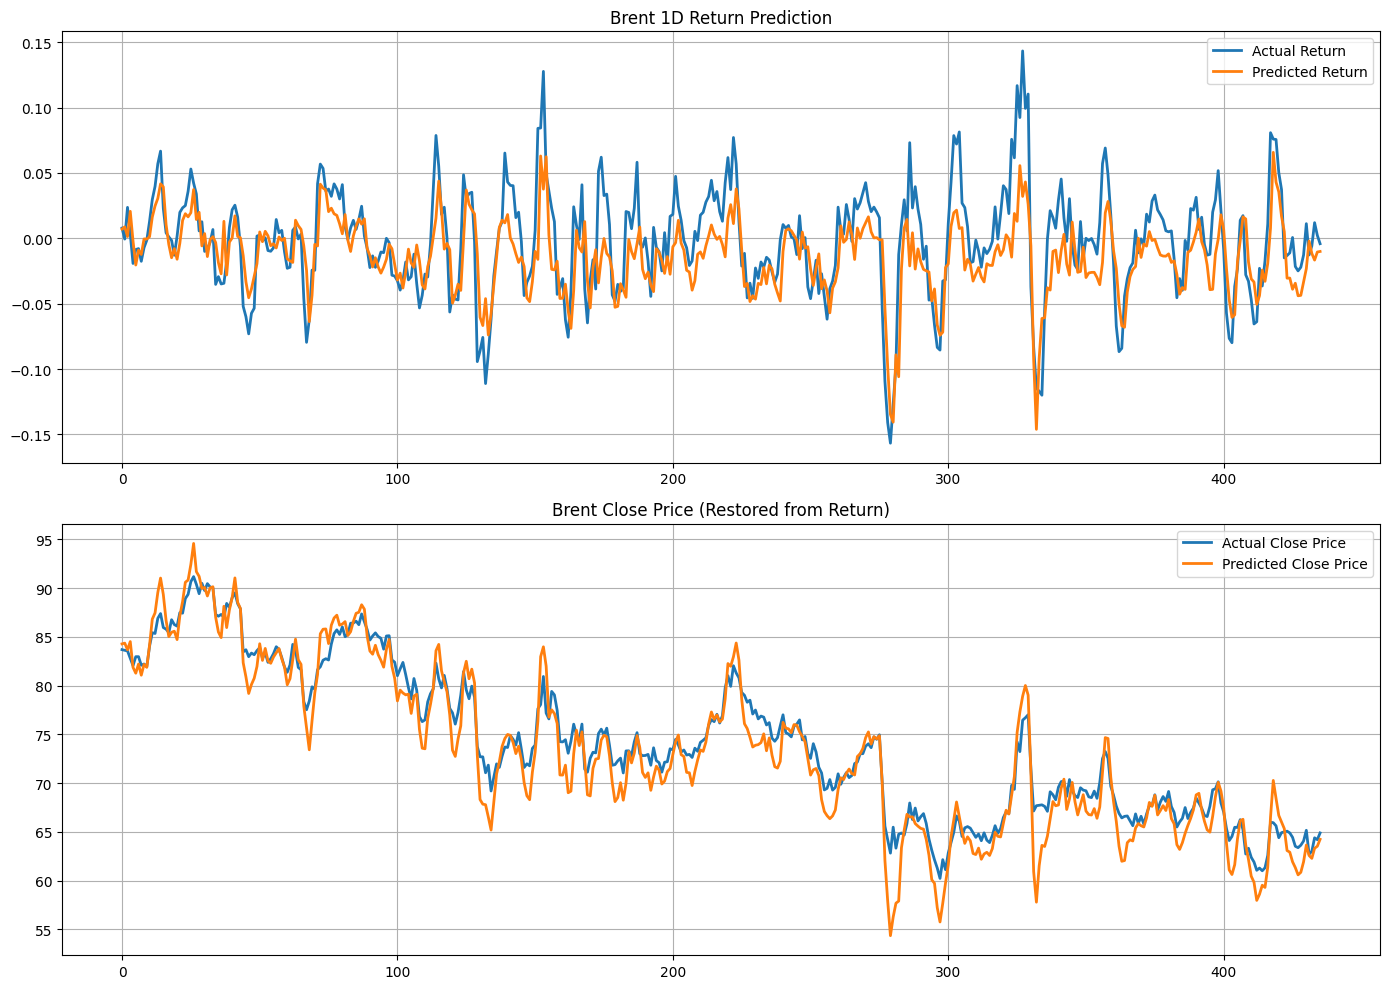

{'model': BiGRU(
   (gru): GRU(26, 64, batch_first=True, bidirectional=True)
   (fc): Linear(in_features=128, out_features=1, bias=True)
 ),
 'metrics': {'rmse': np.float64(0.02957199059939337),
  'mae': 0.02241946079409879,
  'direction_accuracy': np.float64(0.7270642201834863)},
 'prediction': {'y_test': array([ 7.82851422e-03, -5.97531056e-04,  2.36461681e-02,  3.27158944e-03,
         -1.92468689e-02, -8.60422106e-03, -7.89289214e-03, -1.75942689e-02,
         -7.12565152e-03, -1.46273458e-03,  1.28977785e-02,  2.96528340e-02,
          3.97172811e-02,  5.69273854e-02,  6.66503809e-02,  2.28489610e-02,
          4.21447691e-03,  1.05465164e-03, -1.61122558e-03, -1.29319900e-02,
          1.62884694e-03,  1.98181931e-02,  2.32938998e-02,  2.50143881e-02,
          3.59420113e-02,  5.29678869e-02,  4.21810090e-02,  3.38595189e-02,
          5.62303205e-03,  1.26469491e-02, -1.00386503e-02, -7.89734820e-03,
         -3.09801713e-03,  6.70989137e-03, -3.52564359e-02, -2.93068567e-02,
 

In [39]:
df = features_b.copy()
result = run_bigru_pipeline(df)
result

# B-1 EIA 데이터에서 파생변수만 쓰기

In [13]:
cols_to_remove = [
    "crude_stock_level", "gas_stock_level", "dist_stock_level",
    "crude_imports", "crude_exports", "net_imports",
    "prod_weekly", "prod_4w_ma", "prod_wow_change",
    "import_4w_ma",
    "refinery_run_rate"
]
features_b_1 = features_b.drop(columns=[c for c in features_b.columns 
                                      if any(k in c for k in [
                                          "stock_", "imports", "export", 
                                          "prod_", "refinery"
                                      ])])


[Epoch 01] train=0.25426, val=0.04255
[Epoch 02] train=0.08307, val=0.02211
[Epoch 03] train=0.07445, val=0.02071
[Epoch 04] train=0.07033, val=0.02169
[Epoch 05] train=0.07087, val=0.02029
[Epoch 06] train=0.07111, val=0.01952
[Epoch 07] train=0.07802, val=0.02046
[Epoch 08] train=0.07535, val=0.02196
[Epoch 09] train=0.06552, val=0.02243
[Epoch 10] train=0.06928, val=0.02128
[Epoch 11] train=0.06375, val=0.01897
[Epoch 12] train=0.06345, val=0.02805
[Epoch 13] train=0.06158, val=0.02064
[Epoch 14] train=0.06484, val=0.02273
[Epoch 15] train=0.06335, val=0.02331
[Epoch 16] train=0.06682, val=0.02050
[Epoch 17] train=0.06786, val=0.02270
[Epoch 18] train=0.05948, val=0.02272
[Epoch 19] train=0.06143, val=0.01967
[Epoch 20] train=0.05642, val=0.02054
[Epoch 21] train=0.06065, val=0.02098
[Epoch 22] train=0.06054, val=0.02061
[Epoch 23] train=0.06066, val=0.02133
[Epoch 24] train=0.05916, val=0.01821
[Epoch 25] train=0.05770, val=0.02134
[Epoch 26] train=0.05788, val=0.01932
[Epoch 27] t

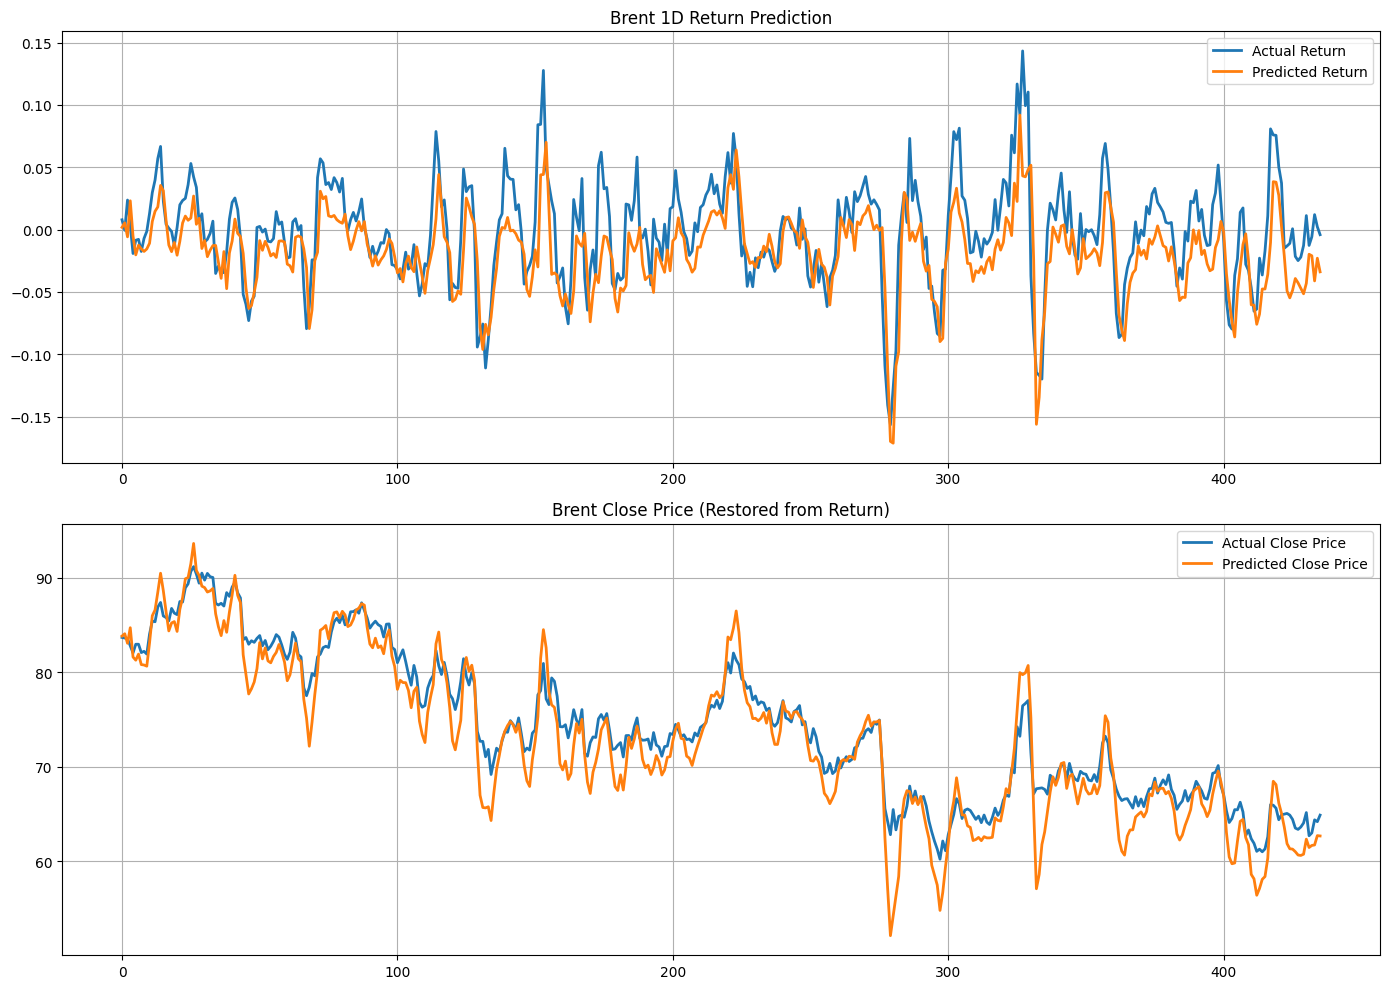

{'model': BiGRU(
   (gru): GRU(20, 64, batch_first=True, bidirectional=True)
   (fc): Linear(in_features=128, out_features=1, bias=True)
 ),
 'metrics': {'rmse': np.float64(0.03063939075966924),
  'mae': 0.02389047060215244,
  'direction_accuracy': np.float64(0.7155963302752294)},
 'prediction': {'y_test': array([ 7.82851422e-03, -5.97531056e-04,  2.36461681e-02,  3.27158944e-03,
         -1.92468689e-02, -8.60422106e-03, -7.89289214e-03, -1.75942689e-02,
         -7.12565152e-03, -1.46273458e-03,  1.28977785e-02,  2.96528340e-02,
          3.97172811e-02,  5.69273854e-02,  6.66503809e-02,  2.28489610e-02,
          4.21447691e-03,  1.05465164e-03, -1.61122558e-03, -1.29319900e-02,
          1.62884694e-03,  1.98181931e-02,  2.32938998e-02,  2.50143881e-02,
          3.59420113e-02,  5.29678869e-02,  4.21810090e-02,  3.38595189e-02,
          5.62303205e-03,  1.26469491e-02, -1.00386503e-02, -7.89734820e-03,
         -3.09801713e-03,  6.70989137e-03, -3.52564359e-02, -2.93068567e-02,
 

In [41]:
df = features_b_1.copy()
result = run_bigru_pipeline(df)
result

# C. COT 추가

In [12]:
def fetch_cot_raw(start_year=2009, end_year=2025):
    base_url = "https://www.cftc.gov/files/dea/history/fut_disagg_txt_{}.zip"
    all_df = []

    for year in range(start_year, end_year + 1):
        url = base_url.format(year)

        try:
            res = requests.get(url)
            res.raise_for_status()

            with zipfile.ZipFile(BytesIO(res.content)) as z:
                for name in z.namelist():
                    if name.endswith(".txt"):
                        df = pd.read_csv(z.open(name), header=None)
                        df["year"] = year
                        all_df.append(df)

        except:
            pass  # 조용히 skip

    if len(all_df) == 0:
        raise RuntimeError("COT raw 다운로드 실패")

    df_all = pd.concat(all_df, ignore_index=True)
    return df_all

def extract_cot_features(df_all):
    """
    df_all: CFTC disagg futures raw merged
    반환: cot_daily (날짜 index)
    """

    # ----- 헤더 처리 -----
    if df_all.iloc[0, 0] == "Market_and_Exchange_Names":
        df_all.columns = df_all.iloc[0]
        df_all = df_all.drop(index=0).reset_index(drop=True)

    df_all.columns = [str(c).strip() for c in df_all.columns]
    df_all = df_all.rename(columns=lambda x: x.replace("-", "_").replace(" ", "_"))

    # 날짜 컬럼 자동 탐색
    date_col = next((c for c in df_all.columns if "report_date" in c.lower()), None)
    df_all["date"] = pd.to_datetime(df_all[date_col], errors="coerce")

    # 핵심 포지션 컬럼
    mm_long = "M_Money_Positions_Long_All"
    mm_short = "M_Money_Positions_Short_All"
    prod_short = "Prod_Merc_Positions_Short_All"
    oi_col = "Open_Interest_All"

    # 숫자 처리
    for col in [mm_long, mm_short, prod_short, oi_col]:
        if col in df_all.columns:
            df_all[col] = pd.to_numeric(df_all[col], errors="coerce")

    # 시장명 소문자
    df_all["Market_and_Exchange_Names"] = (
        df_all["Market_and_Exchange_Names"].astype(str).str.lower()
    )

    # WTI만 필터링
    wti = df_all[
        df_all["Market_and_Exchange_Names"].str.contains("crude oil, light sweet", na=False)
    ].copy()

    # ----- 피처 생성 -----
    wti = (
        wti.sort_values("date")
           .groupby("date", as_index=False)
           .last()
    )

    wti["wti_mm_net_long"] = wti[mm_long] - wti[mm_short]
    wti["wti_mm_net_long_ratio"] = wti["wti_mm_net_long"] / wti[oi_col]
    wti["wti_producer_hedge_ratio"] = wti[prod_short] / wti[oi_col]
    wti["wti_mm_position_change_wow"] = wti["wti_mm_net_long"].diff()
    wti["wti_sentiment_position"] = np.sign(wti["wti_mm_net_long"])

    cot_weekly = wti.set_index("date")[
        [
            "wti_mm_net_long",
            "wti_mm_net_long_ratio",
            "wti_producer_hedge_ratio",
            "wti_mm_position_change_wow",
            "wti_sentiment_position",
        ]
    ]

    # ----- 주간 → 일간 변환 -----
    cot_daily = cot_weekly.resample("D").ffill()
    return cot_daily

def add_cot_to_features(features_df, cot_daily):
    """
    features_df: Brent/WTI input feature dataframe
    cot_daily : extract_cot_features() output
    """

    # index가 datetime이어야 merge 안전
    df = features_df.copy()
    df.index = pd.to_datetime(df.index)

    cot_daily = cot_daily.copy()
    cot_daily.index = pd.to_datetime(cot_daily.index)

    # 일간 forward fill된 COT를 feature에 붙임
    merged = df.join(cot_daily, how="left")

    # 결측 채움 (초반 기간에 해당)
    merged = merged.fillna(method="ffill").fillna(method="bfill")

    return merged


In [13]:
# 1) RAW 다운로드
df_all = fetch_cot_raw()

# 2) 파생변수 추출
cot_daily = extract_cot_features(df_all)

# 3) 기존 features에 merge
features_with_cot = add_cot_to_features(features_b_1, cot_daily)

# 4) GRU 실행
# result = run_bigru_pipeline(features_with_cot)
# result


C:\Users\SKAX\AppData\Local\Temp\ipykernel_35524\4176304119.py:15: DtypeWarning: Columns (1,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,131,132,147,148,149,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,188) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(z.open(name), header=None)
C:\Users\SKAX\AppData\Local\Temp\ipykernel_35524\4176304119.py:15: DtypeWarning: Columns (1,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105

NameError: name 'features_b_1' is not defined

# D. A + EIA + COT

In [ ]:
# 1) EIA 붙인 features_b
df_eia = features_b.copy()

# 2) COT raw 다운로드
df_all = fetch_cot_raw()

# 3) COT 파생변수 생성
cot_daily = extract_cot_features(df_all)

# 4) EIA + COT merge
df_final = add_cot_to_features(df_eia, cot_daily)

# 5) GRU 학습
# result = run_bigru_pipeline(df_final)
# result


C:\Users\SKAX\AppData\Local\Temp\ipykernel_30756\4176304119.py:15: DtypeWarning: Columns (1,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,131,132,147,148,149,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,188) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(z.open(name), header=None)
C:\Users\SKAX\AppData\Local\Temp\ipykernel_30756\4176304119.py:15: DtypeWarning: Columns (1,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105

# E. A + 뉴스 sentiment

In [25]:
def prepare_news_df(news_list):
    """
    news_list: JSON 데이터 리스트
    반환: date, sentiment만 정리된 DataFrame
    """
    rows = []
    for item in news_list:
        date = item.get("date_only") or item.get("date")  # date_only 우선 사용
        sent = None

        # sentiment 구조: { "score": -0.8, "explanation": "..."}
        if "sentiment" in item and isinstance(item["sentiment"], dict):
            sent = item["sentiment"].get("score", None)

        if date is not None and sent is not None:
            rows.append({"date": date, "sentiment": sent})

    df = pd.DataFrame(rows)
    df["date"] = pd.to_datetime(df["date"])
    return df

def aggregate_daily_sentiment(news_df):
    """
    date, sentiment 컬럼 가진 df → 일별 뉴스 피처 생성
    """
    daily = news_df.groupby("date").agg(
        news_sentiment_mean = ("sentiment", "mean"),
        news_sentiment_sum = ("sentiment", "sum"),
        news_sentiment_abs_sum = ("sentiment", lambda x: x.abs().sum()),
        news_count = ("sentiment", "count")
    )
    return daily

def merge_news_features(features_df, news_daily_df):
    """
    features_df : 브렌트/WTI/EIA/COT 등 포함한 기존 DF
    news_daily_df: aggregate_daily_sentiment 결과 DF
    """
    merged = features_df.merge(
        news_daily_df,
        left_index=True, 
        right_index=True,
        how="left"
    )

    # 뉴스 없는 날은 0으로 채우기
    merged = merged.fillna({
        "news_sentiment_mean": 0,
        "news_sentiment_sum": 0,
        "news_sentiment_abs_sum": 0,
        "news_count": 0
    })

    return merged


[Epoch 01] train=0.15704, val=0.01764
[Epoch 02] train=0.08570, val=0.01913
[Epoch 03] train=0.07467, val=0.02489
[Epoch 04] train=0.07736, val=0.02587
[Epoch 05] train=0.07589, val=0.02020
[Epoch 06] train=0.07795, val=0.01615
[Epoch 07] train=0.06997, val=0.01730
[Epoch 08] train=0.07036, val=0.01700
[Epoch 09] train=0.07189, val=0.01705
[Epoch 10] train=0.06298, val=0.02467
[Epoch 11] train=0.06647, val=0.01684
[Epoch 12] train=0.06381, val=0.01930
[Epoch 13] train=0.06400, val=0.02014
[Epoch 14] train=0.06619, val=0.01951
[Epoch 15] train=0.06377, val=0.02242
[Epoch 16] train=0.06499, val=0.01864
[Epoch 17] train=0.05952, val=0.01751
[Epoch 18] train=0.06525, val=0.01830
[Epoch 19] train=0.06697, val=0.01689
[Epoch 20] train=0.05779, val=0.01743
[Epoch 21] train=0.06124, val=0.02254
[Epoch 22] train=0.06043, val=0.02406
[Epoch 23] train=0.05978, val=0.01710
[Epoch 24] train=0.05746, val=0.01655
[Epoch 25] train=0.05375, val=0.01726
[Epoch 26] train=0.05541, val=0.02107
[Epoch 27] t

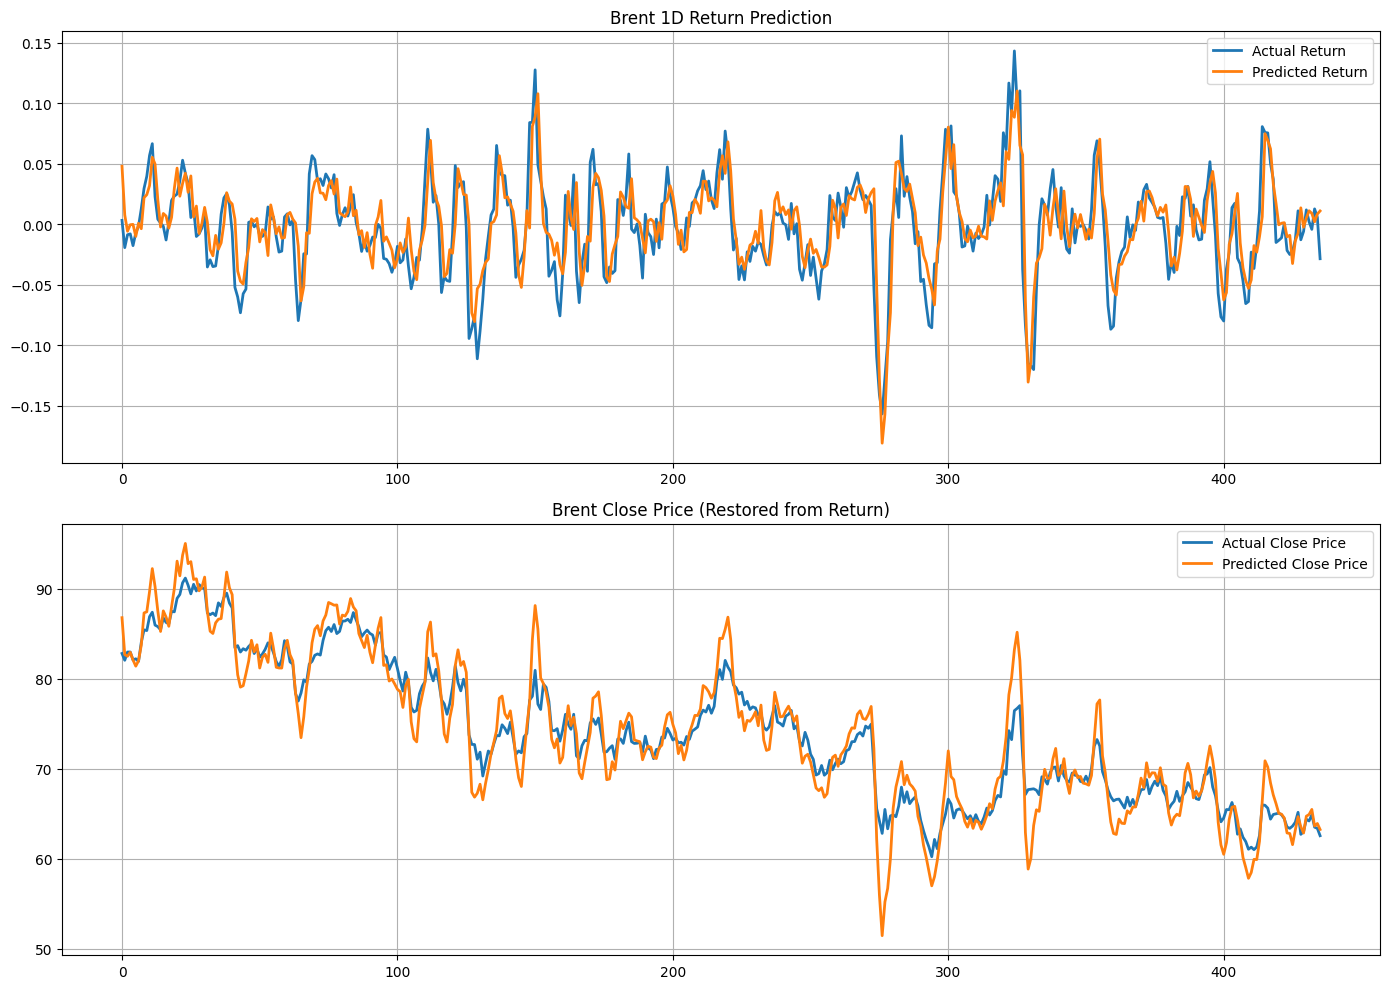

{'model': BiGRU(
   (gru): GRU(15, 64, batch_first=True, bidirectional=True)
   (fc): Linear(in_features=128, out_features=1, bias=True)
 ),
 'metrics': {'rmse': 0.024429941110454163,
  'mae': 0.01829896238760447,
  'direction_accuracy': 0.786697247706422},
 'prediction': {'y_test': array([ 3.27158944e-03, -1.92468689e-02, -8.60422106e-03, -7.89289214e-03,
         -1.75942689e-02, -7.12565152e-03, -1.46273458e-03,  1.28977785e-02,
          2.96528340e-02,  3.97172811e-02,  5.69273854e-02,  6.66503809e-02,
          2.28489610e-02,  4.21447691e-03,  1.05465164e-03, -1.61122558e-03,
         -1.29319900e-02,  1.62884694e-03,  1.98181931e-02,  2.32938998e-02,
          2.50143881e-02,  3.59420113e-02,  5.29678869e-02,  4.21810090e-02,
          3.38595189e-02,  5.62303205e-03,  1.26469491e-02, -1.00386503e-02,
         -7.89734820e-03, -3.09801713e-03,  6.70989137e-03, -3.52564359e-02,
         -2.93068567e-02, -3.49363863e-02, -3.44061990e-02, -1.77738118e-02,
          8.36287914e-03,

In [26]:
with open('../data/embedded.json', 'r', encoding='utf-8') as f:
    news = json.load(f)

# 2) sentiment + date_only 추출
news_df = prepare_news_df(news)

# 3) 일별 집계 생성
news_daily = aggregate_daily_sentiment(news_df)

# 4) 기존 features(A/B/C/D)에 merge
features_E = merge_news_features(features, news_daily)

# # 5) GRU 실험
result = run_bigru_pipeline(features_E)
result

# 일단 얘로 ㅇㅇ

In [27]:
def predict_next_day(df, model, scaler, seq_len=30, target_col="brent_ret_5d"):
    """
    df        : 전체 feature dataframe (training 포함)
    model     : 학습된 GRU 모델
    scaler    : 학습에서 사용된 input scaler
    seq_len   : window 길이
    """

    # === 1) df_input 재생성 (train 때와 똑같게!) ===
    ret_cols = [c for c in df.columns if "ret_" in c and c != target_col]
    df_input = df.drop(columns=ret_cols + ["brent_close", "wti_close"], errors="ignore")

    # === 2) 스케일링 동일 적용 (fit 아님! transform만) ===
    df_scaled = pd.DataFrame(
        scaler.transform(df_input),
        index=df.index,
        columns=df_input.columns
    )

    # === 3) 마지막 seq_len 만큼 슬라이싱 ===
    last_window = df_scaled.iloc[-seq_len:].values
    X_last = np.expand_dims(last_window, axis=0)  # (1, seq_len, feature_dim)

    # === 4) 모델 추론 (return 예측) ===
    model.eval()
    with torch.no_grad():
        pred_ret = model(torch.tensor(X_last, dtype=torch.float32)).numpy()[0][0]

    # === 5) 오늘 close 불러와서 내일 close 복원 ===
    close_today = df["brent_close"].iloc[-1]
    pred_price = close_today * (1 + pred_ret)

    return {
        "pred_return": float(pred_ret),
        "today_close": float(close_today),
        "predicted_tomorrow_close": float(pred_price)
    }


In [28]:
features_new = make_brent_wti_features(
    start="2013-09-01",
    end="2025-11-19",      # ★ 여기까지 끊음
    target_horizon=5
)

features_new = features_new[features_new.index >= "2014-01-01"]


C:\Users\SKAX\AppData\Local\Temp\ipykernel_35524\4108742217.py:23: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["wti_ret_1d"]  = df["wti_close"].pct_change(1)
C:\Users\SKAX\AppData\Local\Temp\ipykernel_35524\4108742217.py:24: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["wti_ret_5d"]  = df["wti_close"].pct_change(5)
C:\Users\SKAX\AppData\Local\Temp\ipykernel_35524\4108742217.py:25: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_me

In [ ]:
features_new.head()

,brent_close,wti_close,brent_wti_spread,brent_ret_1d,brent_ret_5d,wti_ret_1d,brent_ma_5,brent_ma_20,brent_ma_60,wti_ma_5,wti_ma_20,wti_ma_60,brent_vol_5d,wti_vol_5d,high_low_range
Date,,,,,,,,,,,,,,,
2014-01-02,107.779999,95.440002,12.339996,-0.027256,-0.036819,-0.030278,110.790001,110.6705,109.391334,98.604001,97.9800,97.413000,0.011831,0.014810,0.033680
2014-01-03,106.889999,93.959999,12.930000,-0.008258,-0.045455,-0.015507,109.772000,110.3840,109.356167,97.486000,97.8760,97.257167,0.010935,0.013672,0.017214
2014-01-06,106.730003,93.430000,13.300003,-0.001497,-0.048583,-0.005641,108.682001,110.1265,109.310667,96.108000,97.6875,97.083667,0.010182,0.009727,0.012836
2014-01-07,107.349998,93.669998,13.680000,0.005809,-0.034709,0.002569,107.910001,109.9450,109.271834,94.984000,97.5020,96.927667,0.012422,0.012333,0.007452
2014-01-08,107.150002,92.330002,14.820000,-0.001863,-0.032942,-0.014306,107.180000,109.7220,109.221667,93.766000,97.2360,96.741667,0.012569,0.012272,0.008493


In [ ]:
dd.head()

In [18]:
def prepare_news_df(news_list):
    """
    news_list: JSON 데이터 리스트
    반환: date, sentiment만 정리된 DataFrame
    """
    rows = []
    for item in news_list:

        # 1) date_only 우선
        if "date_only" in item:
            date = item["date_only"]

        # 2) published → datetime 변환
        elif "published" in item and isinstance(item["published"], str):
            try:
                # 예: "Nov 19, 2025 at 09:49"
                date = item["published"].split(" at ")[0]
                date = pd.to_datetime(date, format="%b %d, %Y")
            except:
                continue

        # 3) fallback
        else:
            continue

        # sentiment score
        sent = None
        if "sentiment" in item and isinstance(item["sentiment"], dict):
            sent = item["sentiment"].get("score", None)

        if sent is None:
            continue

        rows.append({
            "date": date,
            "sentiment": sent
        })

    df = pd.DataFrame(rows)
    df["date"] = pd.to_datetime(df["date"])

    return df


In [19]:
with open("./extra_embedded (1).json", "r", encoding="utf-8") as f:
    news = json.load(f)

news_df = prepare_news_df(news)
news_daily = aggregate_daily_sentiment(news_df)

In [20]:
features_E_new = merge_news_features(features_new, news_daily)


In [21]:
next_day_pred = predict_next_day(
    df=features_E_new, 
    model=result["model"], 
    scaler=result["scaler"],
    seq_len=30,
    target_col="brent_ret_5d"
)

print(next_day_pred)


NameError: name 'result' is not defined

# F. A + EIA + 뉴스 sentiment
# G. A + COT + 뉴스 sentiment
# H. A + EIA + COT + 뉴스 sentiment

In [19]:
# =========================================
# 1) Base 컬럼 정의
# =========================================
BASE_COLS = None  # run_bigru_pipeline 돌릴 때 자동 설정되므로 None으로 초기화


# =========================================
# 2) 중복 컬럼 자동 제거 후 join하는 안전 함수
# =========================================
def join_safe(left, right):
    # index 정렬 (안전성)
    left = left.sort_index()
    right = right.sort_index()

    # 중복 컬럼 자동 제거
    overlap = [c for c in right.columns if c in left.columns]
    if overlap:
        right = right.drop(columns=overlap)

    return left.join(right, how="left")


# =========================================
# 3) Feature Set 생성 함수 (A, A+EIA, A+COT, A+EIA+COT+NEWS)
# =========================================
def make_feature_sets(base_A, features_eia, features_cot, features_news):
    A = base_A.sort_index()
    eia = features_eia.sort_index()
    cot = features_cot.sort_index()
    news = features_news.sort_index()

    # ---- F: A + EIA + NEWS ----
    F = join_safe(A, eia)
    F = join_safe(F, news)

    # ---- G: A + COT + NEWS ----
    G = join_safe(A, cot)
    G = join_safe(G, news)

    # ---- H: A + EIA + COT + NEWS ----
    H = join_safe(A, eia)
    H = join_safe(H, cot)
    H = join_safe(H, news)

    return {"F": F, "G": G, "H": H}


In [20]:
feature_sets = make_feature_sets(
    base_A = features,          # A: Brent+WTI 기본
    features_eia = features_b,  # B: A+EIA
    features_cot = df_final,    # D: A+EIA+COT
    features_news = features_E  # E: A+NEWS
)

# for name, df in feature_sets.items():
#     print(f"\n===== Running {name} =====")
#     df = df.dropna()
#     result = run_bigru_pipeline(df)
#     result


# 클러스터링 기반

In [31]:
def prepare_timeseries_df(df):
    """
    CSV로부터 읽은 raw DF에서
    Date → datetime 변환 + index 설정 + 소트 + 중복 제거까지 처리
    """
    df = df.copy()

    # 1) Date 컬럼 이름이 'Date' 또는 'date' 뭐든 자동 처리
    date_col = None
    for c in df.columns:
        if c.lower() == "date":
            date_col = c
            break

    if date_col is None:
        raise KeyError("Date 컬럼을 찾지 못했습니다. 'Date' 또는 'date' 이름이어야 합니다.")

    # 2) 날짜 변환
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")

    # 3) 날짜가 NaT인 행 제거
    df = df.dropna(subset=[date_col])

    # 4) index 설정
    df = df.set_index(date_col)

    # 5) 타임소트
    df = df.sort_index()

    # 6) index 중복 제거
    df = df[~df.index.duplicated(keep="last")]

    return df

clust=pd.read_csv('checkpoint_1117_with_cluster30_graph_brent_ridge_impact.csv')
df_ts = prepare_timeseries_df(clust)

print(df_ts.head())


            brent_close  wti_close  brent_wti_spread  brent_ret_1d  \
Date                                                                 
2014-01-02   107.779999  95.440002         12.339996     -0.027256   
2014-01-03   106.889999  93.959999         12.930000     -0.008258   
2014-01-06   106.730003  93.430000         13.300003     -0.001497   
2014-01-07   107.349998  93.669998         13.680000      0.005809   
2014-01-08   107.150002  92.330002         14.820000     -0.001863   

            brent_ret_5d  brent_ret_20d  brent_ma_5  brent_ma_20  brent_ma_60  \
Date                                                                            
2014-01-02     -0.036819      -0.032930  110.790001     110.6705   109.391334   
2014-01-03     -0.045455      -0.050879  109.772000     110.3840   109.356167   
2014-01-06     -0.048583      -0.046031  108.682001     110.1265   109.310667   
2014-01-07     -0.034709      -0.032709  107.910001     109.9450   109.271834   
2014-01-08     -0.03294

In [32]:
def attach_cluster_to_A(base_A, features_cluster):
    """
    base_A : 기존 A (Brent + WTI 기본 피처셋)
    features_cluster : cluster, impact 값이 모두 들어있는 DF
    """

    # 필요 컬럼만 추출
    cluster_cols = [
        "cluster_0","cluster_1","cluster_2","cluster_3","cluster_4",
        "cluster_5","cluster_6","cluster_7","cluster_8",
        "news_impact_brent_day0_value","news_impact_brent_day1_value",
        "news_impact_brent_day2_value","news_impact_brent_day3_value",
        "news_impact_brent_day4_value","news_impact_brent_total"
    ]

    cluster_df = features_cluster[cluster_cols].copy()

    # index(Date) 기준 merge
    A_with_cluster = base_A.join(cluster_df, how="left")

    return A_with_cluster


In [33]:
def attach_cluster_to_H(H, features_cluster):
    """
    H : A + EIA + COT + NEWS 풀 피처셋
    features_cluster : cluster + 영향을 포함한 DF
    """

    cluster_cols = [
        "cluster_0","cluster_1","cluster_2","cluster_3","cluster_4",
        "cluster_5","cluster_6","cluster_7","cluster_8",
        "news_impact_brent_day0_value","news_impact_brent_day1_value",
        "news_impact_brent_day2_value","news_impact_brent_day3_value",
        "news_impact_brent_day4_value","news_impact_brent_total"
    ]

    cluster_df = features_cluster[cluster_cols].copy()

    H_with_cluster = H.join(cluster_df, how="left")

    return H_with_cluster

In [36]:
# A + Cluster
A_with_cluster = attach_cluster_to_A(features, df_ts)

# H + Cluster
H_with_cluster = attach_cluster_to_H(H, df_ts)

# # GRU 학습
# result = run_bigru_pipeline(H_with_cluster.dropna())
# result

AttributeError: 'NoneType' object has no attribute 'join'

---

In [7]:
features.tail()

,brent_close,wti_close,brent_wti_spread,brent_ret_1d,brent_ret_5d,wti_ret_1d,brent_ma_5,brent_ma_20,brent_ma_60,wti_ma_5,wti_ma_20,wti_ma_60,brent_vol_5d,wti_vol_5d,high_low_range
Date,,,,,,,,,,,,,,,
2025-11-18,64.889999,60.740002,4.149998,0.010748,-0.004144,0.013854,63.839999,64.3905,65.495833,59.584,60.2380,61.521667,0.022575,0.025121,0.022654
2025-11-19,63.509998,59.439999,4.070000,-0.021267,0.012757,-0.021403,63.999998,64.4365,65.434000,59.774,60.2850,61.458167,0.016156,0.017203,0.031334
2025-11-20,63.380001,59.139999,4.240002,-0.002047,0.005872,-0.005047,64.073999,64.3060,65.356166,59.864,60.1525,61.374667,0.016219,0.017606,0.022720
2025-11-21,62.560001,58.060001,4.500000,-0.012938,-0.028421,-0.018262,63.707999,64.1370,65.255166,59.458,59.9805,61.265667,0.012105,0.014042,0.020301
2025-11-24,61.410000,57.849998,3.560001,-0.018382,-0.043458,-0.003617,63.150000,63.9265,65.143333,59.046,59.8075,61.163000,0.013154,0.014003,0.013353


In [8]:
features.head()

,brent_close,wti_close,brent_wti_spread,brent_ret_1d,brent_ret_5d,wti_ret_1d,brent_ma_5,brent_ma_20,brent_ma_60,wti_ma_5,wti_ma_20,wti_ma_60,brent_vol_5d,wti_vol_5d,high_low_range
Date,,,,,,,,,,,,,,,
2014-01-02,107.779999,95.440002,12.339996,-0.027256,-0.036819,-0.030278,110.790001,110.6705,109.391334,98.604001,97.9800,97.413000,0.011831,0.014810,0.033680
2014-01-03,106.889999,93.959999,12.930000,-0.008258,-0.045455,-0.015507,109.772000,110.3840,109.356167,97.486000,97.8760,97.257167,0.010935,0.013672,0.017214
2014-01-06,106.730003,93.430000,13.300003,-0.001497,-0.048583,-0.005641,108.682001,110.1265,109.310667,96.108000,97.6875,97.083667,0.010182,0.009727,0.012836
2014-01-07,107.349998,93.669998,13.680000,0.005809,-0.034709,0.002569,107.910001,109.9450,109.271834,94.984000,97.5020,96.927667,0.012422,0.012333,0.007452
2014-01-08,107.150002,92.330002,14.820000,-0.001863,-0.032942,-0.014306,107.180000,109.7220,109.221667,93.766000,97.2360,96.741667,0.012569,0.012272,0.008493


In [9]:
import joblib
from hdbscan import prediction as hdb_pred


def build_full_dataset(
    news: list,
    start="2013-09-01",
    end=None,
    target_horizon=1,
    umap_path="model_weight/umap_64to20.model",
    kmeans_path="model_weight/kmeans_20d_30clusters.model",
    hdbscan_path="model_weight/hdbscan_20d.model",
    max_cluster=30     # KMeans n_clusters
):
    """
    1) 정형 데이터 생성
    2) 뉴스 임베딩 → UMAP → 클러스터링
    3) 날짜 기준 aggregation 후 정형 데이터와 merge
    4) cluster_0 ... cluster_{max_cluster-1} 더미 컬럼 생성
    """

    # -----------------------------------------
    # 1. 정형 데이터
    # -----------------------------------------
    df = make_brent_wti_features(start=start, end=end, target_horizon=target_horizon)
    df["date"] = df.index.date   # merge 편하게 date 컬럼 추가

    # -----------------------------------------
    # 2. 모델 로드
    # -----------------------------------------
    umap_model = joblib.load(umap_path)
    kmeans = joblib.load(kmeans_path)
    hdbscan_model = joblib.load(hdbscan_path)

    # -----------------------------------------
    # 3. 뉴스 → DataFrame 변환
    # -----------------------------------------
    # summary_embedding, published or date가 있다고 가정
    news_df = pd.DataFrame(news).copy()

    # 날짜 변환
    news_df["date"] = pd.to_datetime(news_df["published"]).dt.date

    # 임베딩 추출
    embeddings = np.array(news_df["summary_embedding"].tolist())

    # -----------------------------------------
    # 4. UMAP 변환
    # -----------------------------------------
    emb_20d = umap_model.transform(embeddings)

    # -----------------------------------------
    # 5. 클러스터 예측
    # -----------------------------------------
    km_labels = kmeans.predict(emb_20d)

    hdb_labels, hdb_strength = hdb_pred.approximate_predict(hdbscan_model, emb_20d)
    hdb_labels = hdb_labels.astype(int)

    news_df["cluster_km"] = km_labels
    news_df["cluster_hdb"] = hdb_labels
    news_df["hdb_strength"] = hdb_strength

    # -----------------------------------------
    # 6. 날짜 단위로 집계
    # -----------------------------------------
    # KMeans count (원핫)
    dummies = pd.get_dummies(news_df["cluster_km"], prefix="cluster")

    news_df_with_dummies = pd.concat([news_df[["date"]], dummies], axis=1)

    # 날짜 단위 집계 (sum = count)
    daily_cluster = news_df_with_dummies.groupby("date").sum()

    # -----------------------------------------
    # 7. 정형데이터와 merge
    # -----------------------------------------
    df_final = df.merge(daily_cluster, on="date", how="left")
    df_final = df_final.fillna(0)

    # -----------------------------------------
    # 8. 필요 없는 raw 컬럼 제거
    # -----------------------------------------
    df_final = df_final.drop(columns=["date"])

    return df_final

In [ ]:
def build_full_dataset(
    news: list,
    start="2013-09-01",
    end=None,
    target_horizon=5,
    umap_path="model_weight/umap_64to20.model",
    kmeans_path="model_weight/kmeans_20d_30clusters.model",
    hdbscan_path="model_weight/hdbscan_20d.model",
    max_cluster=30     # KMeans n_clusters
):

In [17]:
with open("../data/embedded.json", "r", encoding="utf-8") as f:
    raw_news = json.load(f)

from datetime import datetime

def normalize_published_date(news_list):
    for item in news_list:
        raw = item.get("published", "").strip()
        if not raw:
            continue

        try:
            dt = datetime.strptime(raw, "%b %d, %Y at %H:%M")
            item["published"] = dt.strftime("%Y-%m-%d")
        except:
            # 예외 케이스 처리 (필요시 포맷 추가)
            item["published"] = None

    return news_list
news = normalize_published_date(raw_news)


In [19]:
new_features=build_full_dataset(news=news,start='2014-01-02', end='2025-11-07', umap_path="../ai/model_weight/umap_64to20.model",
    kmeans_path="../ai/model_weight/kmeans_20d_30clusters.model",
    hdbscan_path="../ai/model_weight/hdbscan_20d.model")

C:\Users\SKAX\AppData\Local\Temp\ipykernel_23332\4108742217.py:23: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["wti_ret_1d"]  = df["wti_close"].pct_change(1)
C:\Users\SKAX\AppData\Local\Temp\ipykernel_23332\4108742217.py:24: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["wti_ret_5d"]  = df["wti_close"].pct_change(5)
C:\Users\SKAX\AppData\Local\Temp\ipykernel_23332\4108742217.py:25: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_me

In [20]:
new_features.head()

,brent_close,wti_close,brent_wti_spread,brent_ret_1d,brent_ret_5d,brent_ret_20d,wti_ret_1d,wti_ret_5d,wti_ret_20d,brent_ma_5,brent_ma_20,brent_ma_60,wti_ma_5,wti_ma_20,wti_ma_60,brent_vol_5d,wti_vol_5d,high_low_range,cluster_0,cluster_1,cluster_2,cluster_3,cluster_4,cluster_5,cluster_6,cluster_7,cluster_8,cluster_9,cluster_10,cluster_11,cluster_12,cluster_13,cluster_14,cluster_15,cluster_16,cluster_17,cluster_18,cluster_19,cluster_20,cluster_21,cluster_22,cluster_23,cluster_24,cluster_25,cluster_26,cluster_27,cluster_28,cluster_29
0,105.620003,99.739998,5.880005,-0.019859,-0.012805,-0.033669,-0.018114,0.005545,-0.034743,107.262001,107.5065,107.855500,100.906000,100.1090,98.630500,0.010387,0.011799,0.025185,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,104.790001,99.620003,5.169998,-0.007858,-0.020929,-0.027561,-0.001203,-0.006383,-0.018038,106.814001,107.3580,107.805667,100.778000,100.0175,98.700167,0.010464,0.010500,0.017273,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,106.150002,100.290001,5.860001,0.012978,-0.015580,-0.018039,0.006726,-0.009775,-0.012505,106.478001,107.2605,107.793333,100.580000,99.9540,98.805667,0.012149,0.009642,0.017146,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,106.720001,101.139999,5.580002,0.005370,-0.012492,-0.020917,0.008475,-0.005213,-0.014038,106.208002,107.1465,107.793167,100.474001,99.8820,98.934167,0.012567,0.010517,0.008527,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,105.820000,100.440002,5.379997,-0.008433,-0.018003,-0.020910,-0.006921,-0.011223,-0.006725,105.820001,107.0335,107.767667,100.246001,99.8480,99.047000,0.012856,0.010842,0.013986,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


[Epoch 01] train=0.27865, val=0.02941
[Epoch 02] train=0.10467, val=0.02949
[Epoch 03] train=0.08081, val=0.02583
[Epoch 04] train=0.06726, val=0.02353
[Epoch 05] train=0.06433, val=0.02187
[Epoch 06] train=0.06299, val=0.03072
[Epoch 07] train=0.05532, val=0.02057
[Epoch 08] train=0.05177, val=0.01998
[Epoch 09] train=0.04997, val=0.02025
[Epoch 10] train=0.04894, val=0.02203
[Epoch 11] train=0.05283, val=0.02429
[Epoch 12] train=0.04325, val=0.02249
[Epoch 13] train=0.04017, val=0.02327
[Epoch 14] train=0.03623, val=0.01913
[Epoch 15] train=0.03442, val=0.01877
[Epoch 16] train=0.03426, val=0.02188
[Epoch 17] train=0.03362, val=0.01937
[Epoch 18] train=0.03619, val=0.02142
[Epoch 19] train=0.03402, val=0.02069
[Epoch 20] train=0.03128, val=0.02256
[Epoch 21] train=0.02865, val=0.02525
[Epoch 22] train=0.02496, val=0.02070
[Epoch 23] train=0.02488, val=0.02225
[Epoch 24] train=0.02349, val=0.02148
[Epoch 25] train=0.02465, val=0.02522
[Epoch 26] train=0.02219, val=0.02469
[Epoch 27] t

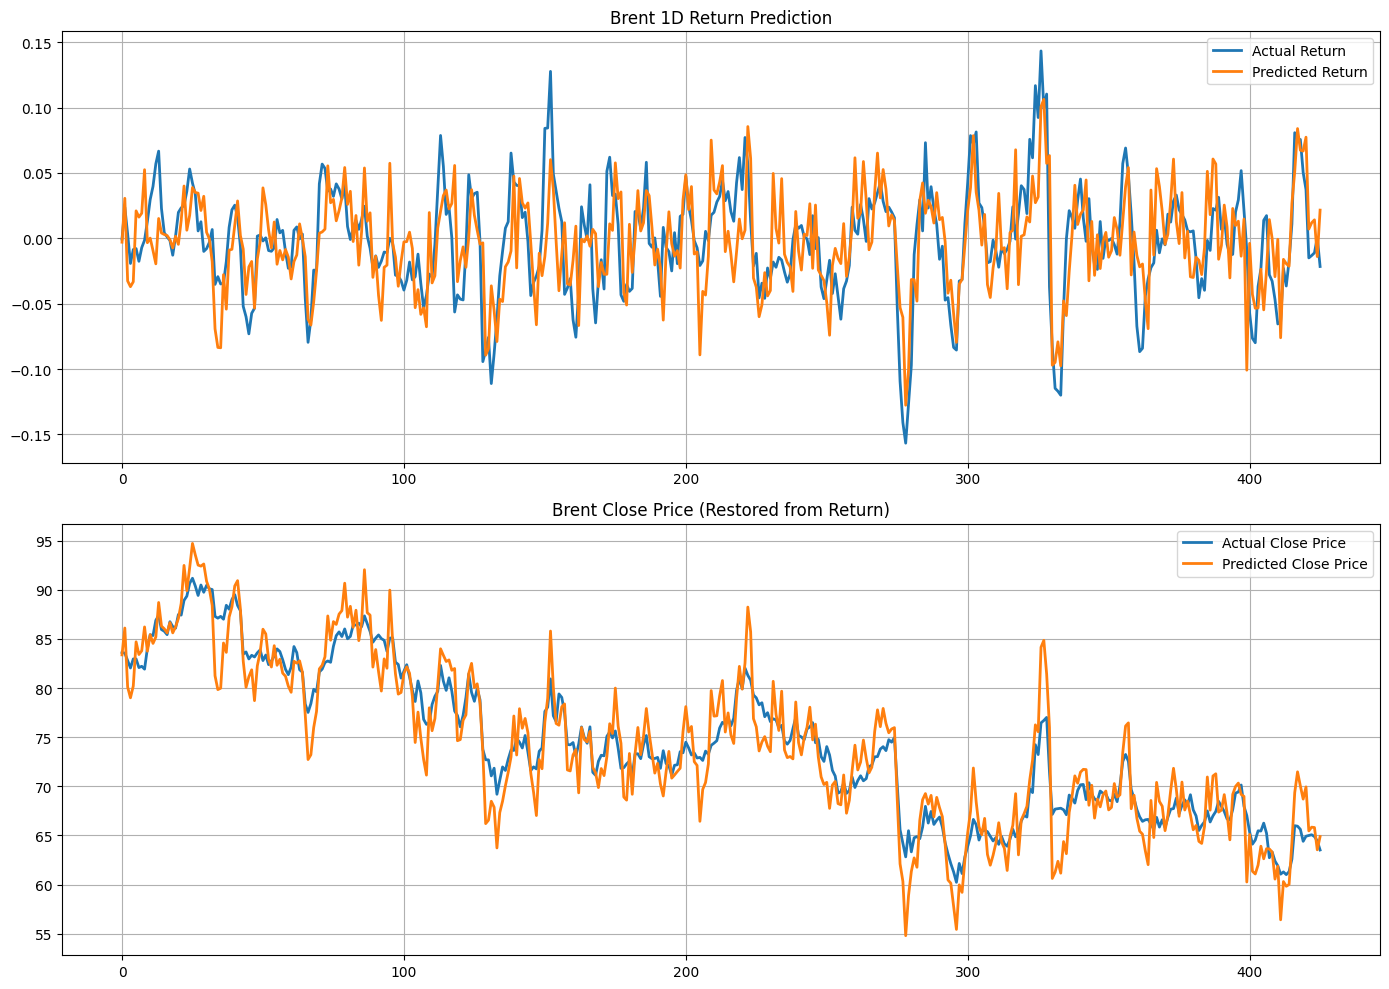

{'model': BiGRU(
   (gru): GRU(41, 64, batch_first=True, bidirectional=True)
   (fc): Linear(in_features=128, out_features=1, bias=True)
 ),
 'metrics': {'rmse': 0.03356242582627886,
  'mae': 0.026386441182834605,
  'direction_accuracy': 0.7018779342723005},
 'prediction': {'y_test': array([-5.97531056e-04,  2.36461681e-02,  3.27158944e-03, -1.92468689e-02,
         -8.60422106e-03, -7.89289214e-03, -1.75942689e-02, -7.12565152e-03,
         -1.46273458e-03,  1.28977785e-02,  2.96528340e-02,  3.97172811e-02,
          5.69273854e-02,  6.66503809e-02,  2.28489610e-02,  4.21447691e-03,
          1.05465164e-03, -1.61122558e-03, -1.29319900e-02,  1.62884694e-03,
          1.98181931e-02,  2.32938998e-02,  2.50143881e-02,  3.59420113e-02,
          5.29678869e-02,  4.21810090e-02,  3.38595189e-02,  5.62303205e-03,
          1.26469491e-02, -1.00386503e-02, -7.89734820e-03, -3.09801713e-03,
          6.70989137e-03, -3.52564359e-02, -2.93068567e-02, -3.49363863e-02,
         -3.44061990e-02

In [21]:
result = run_bigru_pipeline(new_features)
result

In [24]:
import numpy as np
import torch
import pandas as pd

def explain_feature_importance(model, X_sample, feature_names):
    """
    X_sample : shape (seq_len, feature_dim)
    """
    model.eval()
    base = model(torch.tensor(X_sample[None], dtype=torch.float32)).item()

    importances = {}

    for i, feat in enumerate(feature_names):
        x_mod = X_sample.copy()
        x_mod[:, i] = 0  # mask feature i 전체

        mod_pred = model(torch.tensor(x_mod[None], dtype=torch.float32)).item()

        importances[feat] = abs(mod_pred - base)

    # 중요도 정렬
    importances = dict(sorted(importances.items(), key=lambda x: x[1], reverse=True))
    return importances


In [25]:
def explain_temporal_importance(model, X_sample):
    """
    X_sample : (seq_len, feature_dim)
    """
    seq_len = X_sample.shape[0]
    model.eval()

    base = model(torch.tensor(X_sample[None], dtype=torch.float32)).item()

    impacts = []

    for t in range(seq_len):
        x_mod = X_sample.copy()
        x_mod[t, :] = 0  # t번째 시점 전체 mask

        mod_pred = model(torch.tensor(x_mod[None], dtype=torch.float32)).item()
        impacts.append(abs(mod_pred - base))

    return impacts  # 리스트 (seq_len 길이)


In [11]:
# ============================
# 1) 뉴스 날짜·감성만 정리
# ============================

def prepare_news_df(raw_news):
    rows = []

    for item in raw_news:

        # --- 날짜 처리 ---
        if "date_only" in item:
            date = item["date_only"]

        elif "published" in item and isinstance(item["published"], str):
            try:
                d = item["published"].split(" at ")[0]     # "Nov 19, 2025"
                date = pd.to_datetime(d, format="%b %d, %Y")
            except:
                continue
        else:
            continue

        # --- sentiment score ---
        sent = None
        if isinstance(item.get("sentiment"), dict):
            sent = item["sentiment"].get("score", None)
        if sent is None:
            continue

        rows.append({"date": date, "sentiment": sent})

    df_news = pd.DataFrame(rows)
    df_news["date"] = pd.to_datetime(df_news["date"])
    return df_news


# ============================
# 2) 뉴스 일별 집계
# ============================

def aggregate_daily_sentiment(df_news):
    return df_news.groupby("date").agg(
        news_sentiment_mean=("sentiment", "mean"),
        news_sentiment_sum=("sentiment", "sum"),
        news_sentiment_abs_sum=("sentiment", lambda x: x.abs().sum()),
        news_count=("sentiment", "count"),
    )


# ============================
# 3) 기존 피처와 뉴스 병합
# ============================

def merge_news_features(df_features, df_news_daily):
    df_merged = df_features.merge(
        df_news_daily, left_index=True, right_index=True, how="left"
    )

    df_merged = df_merged.fillna({
        "news_sentiment_mean": 0,
        "news_sentiment_sum": 0,
        "news_sentiment_abs_sum": 0,
        "news_count": 0
    })
    return df_merged


In [31]:
# ----------------------------
# 1) 뉴스 로드
# ----------------------------
with open("./extra_embedded (1).json", "r", encoding="utf-8") as f:
    raw_news = json.load(f)

df_news = prepare_news_df(raw_news)
df_news_daily = aggregate_daily_sentiment(df_news)


# ----------------------------
# 2) 기존 피처셋 준비
# ----------------------------
df_base = make_brent_wti_features(target_horizon=5)
df_base = df_base[df_base.index >= "2014-01-01"]


# ----------------------------
# 3) 기존 피처 + 뉴스 병합
# ----------------------------
df_features = merge_news_features(df_base, df_news_daily)


# ----------------------------
# 4) 최신 구간 포함한 데이터 생성
#     (예: 2025-11-19 포함)
# ----------------------------
df_features_new = df_features.copy()


# ----------------------------
# 5) 다음날 예측
# ----------------------------
pred_next_day = predict_next_day(
    df=features_E_new, 
    model=result["model"], 
    scaler=result["scaler"],
    seq_len=30,
    target_col="brent_ret_5d"
)



print(pred_next_day)


C:\Users\SKAX\AppData\Local\Temp\ipykernel_19844\573625205.py:23: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["wti_ret_1d"]  = df["wti_close"].pct_change(1)
C:\Users\SKAX\AppData\Local\Temp\ipykernel_19844\573625205.py:24: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["wti_ret_5d"]  = df["wti_close"].pct_change(5)
C:\Users\SKAX\AppData\Local\Temp\ipykernel_19844\573625205.py:25: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_metho

{'pred_return': -0.0014860648661851883, 'today_close': 64.88999938964844, 'predicted_tomorrow_close': 64.79356876225575}


In [45]:
from captum.attr import IntegratedGradients


def explain_gru_prediction_ig(model, X_sample, feature_names):
    """
    X_sample: (seq_len, feature_dim)
    """

    model.eval()

    ig = IntegratedGradients(model)

    # captum은 batch dimension 필요
    X_tensor = torch.tensor(X_sample[None, :, :], dtype=torch.float32)

    # IG 계산
    attributions, delta = ig.attribute(
        X_tensor,
        n_steps=50,
        return_convergence_delta=True
    )

    # numpy로 변환
    attr = attributions.squeeze(0).detach().numpy()  # (seq_len, feature_dim)

    # feature importance = 전체 시퀀스에 대해 평균(|attribution|)
    importance = np.mean(np.abs(attr), axis=0)

    # JSON-friendly 변환
    return [
        {"feature": feature_names[i], "importance": float(importance[i])}
        for i in range(len(feature_names))
    ]


In [66]:
def predict_with_xai_and_save(model, scaler, df, train_windows, feature_names,
                              seq_len=30, target_col="brent_ret_5d",
                              save_path="prediction.json"):

    # 1) 입력 구성
    ret_cols = [c for c in df.columns if "ret_" in c and c != target_col]
    df_input = df.drop(columns=ret_cols + ["brent_close", "wti_close"], errors="ignore")

    # 2) 스케일링
    df_scaled = scaler.transform(df_input)
    X_last = df_scaled[-seq_len:]

    # 3) return 예측
    X_tensor = torch.tensor(X_last[None, :, :], dtype=torch.float32)
    with torch.no_grad():
        pred_ret = float(model(X_tensor).numpy().reshape(-1)[0])

    # 4) 가격 복원
    today_close = float(df["brent_close"].iloc[-1])
    pred_close = today_close * (1 + pred_ret)

    # 5) XAI (Integrated Gradients)
    xai_result = explain_gru_prediction_ig(
        model=model,
        X_sample=X_last,
        feature_names=feature_names
    )

    # 6) JSON 저장
    output = {
        "prediction": {
            "pred_return": pred_ret,
            "today_close": today_close,
            "predicted_next_close": pred_close
        },
        "xai": xai_result
    }

    with open(save_path, "w", encoding="utf-8") as f:
        json.dump(output, f, ensure_ascii=False, indent=2)

    return output


In [67]:
# def predict_with_xai_and_save(model, scaler, df, train_windows, feature_names,
#                               seq_len=30, target_col="brent_ret_5d",
#                               save_path="prediction.json"):

#     # 1) 입력 구성
#     ret_cols = [c for c in df.columns if "ret_" in c and c != target_col]
#     df_input = df.drop(columns=ret_cols + ["brent_close", "wti_close"], errors="ignore")

#     # 2) 스케일링
#     df_scaled = scaler.transform(df_input)
#     X_last = df_scaled[-seq_len:]

#     # 3) return 예측
#     X_tensor = torch.tensor(X_last[None, :, :], dtype=torch.float32)
#     with torch.no_grad():
#         pred_ret = float(model(X_tensor).numpy().reshape(-1)[0])

#     # 4) 가격 복원
#     today_close = float(df["brent_close"].iloc[-1])
#     pred_close = today_close * (1 + pred_ret)

#     # 5) XAI (Integrated Gradients)
#     xai_result = explain_gru_prediction_ig(
#         model=model,
#         X_sample=X_last,
#         feature_names=feature_names
#     )

#     # 6) JSON 저장
#     output = {
#         "prediction": {
#             "pred_return": pred_ret,
#             "today_close": today_close,
#             "predicted_next_close": pred_close
#         },
#         "xai": xai_result
#     }

#     with open(save_path, "w", encoding="utf-8") as f:
#         json.dump(output, f, ensure_ascii=False, indent=2)

#     return output


[Epoch 01] train=0.11866, val=0.02138
[Epoch 02] train=0.08147, val=0.01657
[Epoch 03] train=0.09057, val=0.01846
[Epoch 04] train=0.08025, val=0.01601
[Epoch 05] train=0.06950, val=0.02192
[Epoch 06] train=0.06814, val=0.01648
[Epoch 07] train=0.06765, val=0.01697
[Epoch 08] train=0.06763, val=0.01645
[Epoch 09] train=0.06808, val=0.01677
[Epoch 10] train=0.07127, val=0.01879
[Epoch 11] train=0.07271, val=0.01943
[Epoch 12] train=0.06566, val=0.01656
[Epoch 13] train=0.06139, val=0.01612
[Epoch 14] train=0.06666, val=0.01955
[Epoch 15] train=0.05995, val=0.01964
[Epoch 16] train=0.05880, val=0.01761
[Epoch 17] train=0.06072, val=0.01630
[Epoch 18] train=0.05886, val=0.02036
[Epoch 19] train=0.05792, val=0.01681
[Epoch 20] train=0.05647, val=0.01923
[Epoch 21] train=0.05450, val=0.01884
[Epoch 22] train=0.05389, val=0.01766
[Epoch 23] train=0.05640, val=0.01941
[Epoch 24] train=0.05150, val=0.02189
[Epoch 25] train=0.05458, val=0.01946
[Epoch 26] train=0.05280, val=0.01750
[Epoch 27] t

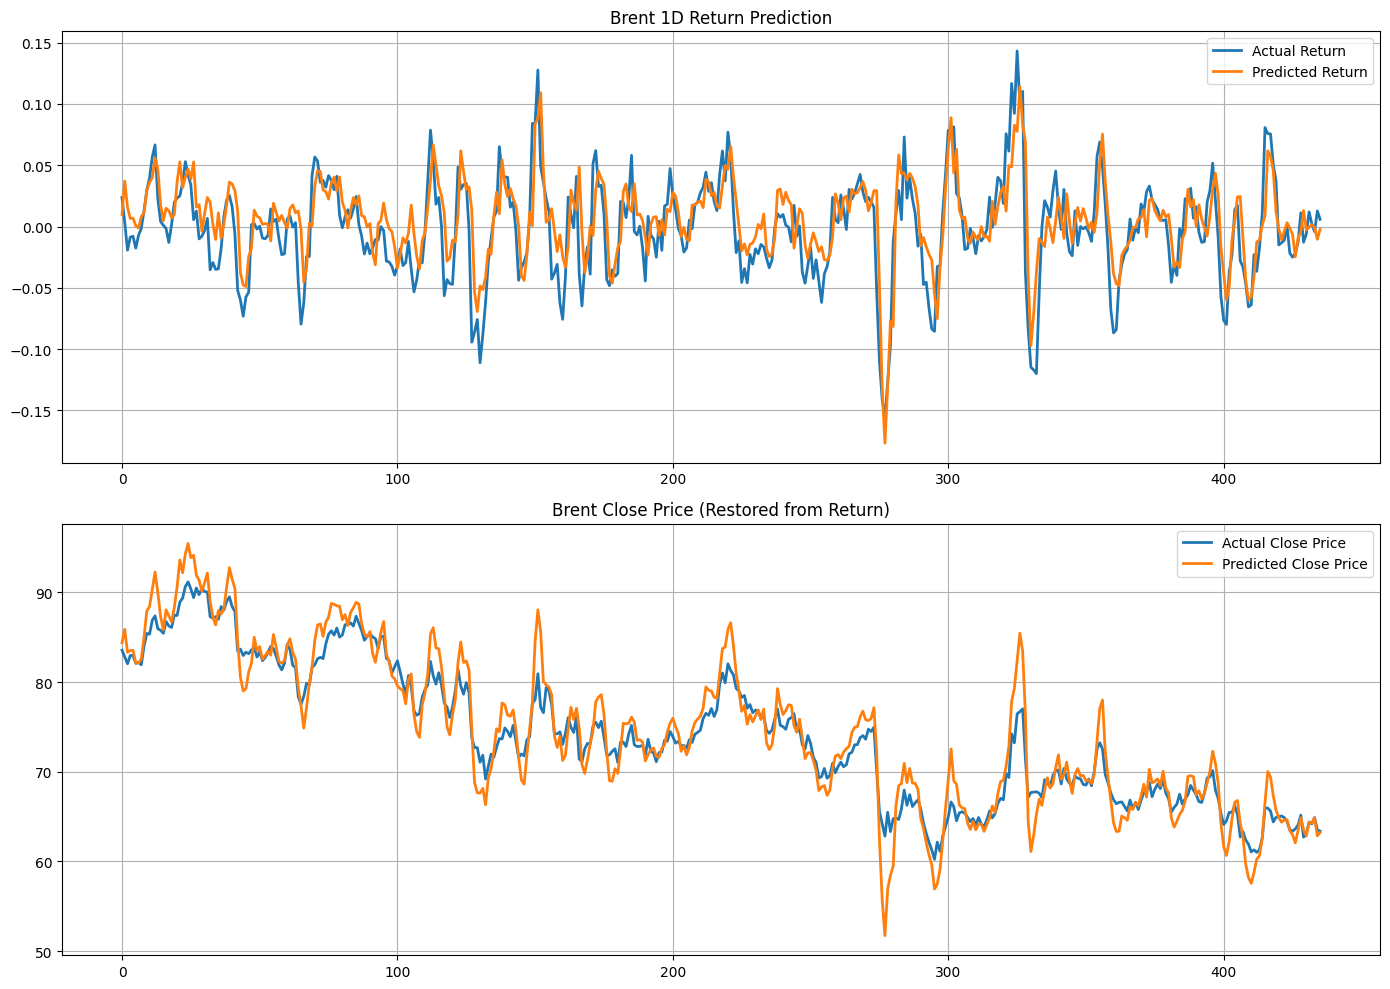

{'prediction': {'pred_return': -0.012175140902400017, 'today_close': 64.88999938964844, 'predicted_next_close': 64.09995450392282}, 'xai': [{'feature': 'brent_wti_spread', 'importance': 4.781333336723037e-05}, {'feature': 'brent_ret_5d', 'importance': 0.00027765269624069333}, {'feature': 'brent_ma_5', 'importance': 0.0001949554862221703}, {'feature': 'brent_ma_20', 'importance': 0.00024456373648718}, {'feature': 'brent_ma_60', 'importance': 0.0001506763364886865}, {'feature': 'wti_ma_5', 'importance': 0.00020346505334600806}, {'feature': 'wti_ma_20', 'importance': 0.00010274509259033948}, {'feature': 'wti_ma_60', 'importance': 6.198642950039357e-05}, {'feature': 'brent_vol_5d', 'importance': 0.00015007374167907983}, {'feature': 'wti_vol_5d', 'importance': 5.615661575575359e-05}, {'feature': 'high_low_range', 'importance': 0.0001968461729120463}, {'feature': 'news_sentiment_mean', 'importance': 7.352155080297962e-05}, {'feature': 'news_sentiment_sum', 'importance': 0.0001194669894175604

In [69]:
result = run_bigru_pipeline(features_E)

pred_json = predict_with_xai_and_save(
    model=result["model"],
    scaler=result["scaler"],
    df=features_E_new,
    train_windows=result["train_windows"],
    feature_names=result["feature_names"],
    seq_len=30,
    target_col="brent_ret_5d",
    save_path="prediction_2025_11_19.json"
)

print(pred_json)


---

In [ ]:
이제 이걸 바탕으로 mi에서 쓰는 대응책 3가지를 llm 써서 만들어야 하거든?
지금은 wti, brent, 뉴스 가지고만 분석했지만,
여기 프롬프트에는 eia랑 cot 데이터도 주는게 좋겠지?

In [1]:
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

dd=pd.read_csv('checkpoint_1117_with_cluster9_graph_ver1.csv')
dd.head()

,Date,brent_close,wti_close,brent_wti_spread,brent_ret_1d,brent_ret_5d,brent_ret_20d,brent_ma_5,brent_ma_20,brent_ma_60,brent_vol_5d,high_low_range,crude_stock_level,gas_stock_level,dist_stock_level,crude_stock_wow_change,gas_stock_wow_change,dist_stock_wow_change,crude_stock_vs_5yr_avg,gas_stock_vs_5yr_avg,dist_stock_vs_5yr_avg,prod_weekly,prod_4w_ma,prod_wow_change,crude_exports,crude_imports,import_4w_ma,net_imports,refinery_run_rate,wti_mm_net_long,wti_mm_net_long_ratio,wti_producer_hedge_ratio,wti_mm_position_change_wow,wti_sentiment_position,DXY_DX-Y.NYB,XLE_XLE,VDE_VDE,IXC_IXC,"('DXY', 'DX-Y.NYB')_ret_1d","('XLE', 'XLE')_ret_1d","('VDE', 'VDE')_ret_1d","('IXC', 'IXC')_ret_1d",us10y_yield,us2y_yield,term_spread,bdi_price,bdi_open,bdi_high,bdi_low,bdi_change_%,wti_mm_net_long_is_update,wti_mm_net_long_shock_raw,wti_mm_net_long_days_since_update,wti_mm_net_long_avail,wti_mm_net_long_shock_decay,wti_mm_net_long_ratio_is_update,wti_mm_net_long_ratio_shock_raw,wti_mm_net_long_ratio_days_since_update,wti_mm_net_long_ratio_avail,wti_mm_net_long_ratio_shock_decay,wti_producer_hedge_ratio_is_update,wti_producer_hedge_ratio_shock_raw,wti_producer_hedge_ratio_days_since_update,wti_producer_hedge_ratio_avail,wti_producer_hedge_ratio_shock_decay,wti_mm_position_change_wow_is_update,wti_mm_position_change_wow_shock_raw,wti_mm_position_change_wow_days_since_update,wti_mm_position_change_wow_avail,wti_mm_position_change_wow_shock_decay,wti_sentiment_position_is_update,wti_sentiment_position_shock_raw,wti_sentiment_position_days_since_update,wti_sentiment_position_avail,wti_sentiment_position_shock_decay,event_large_move,flag_crude_stock_wow_change,flag_prod_wow_change,flag_wti_mm_position_change_wow,wti_producer_hedge_ratio_lag3,wti_producer_hedge_ratio_lag5,spread_regime,spread_regime_code,spread_extreme,spread_chg_5d,crude_vs5_regime,crude_vs5_regime_code,crude_vs5_extreme,crude_vs5_zscore,cluster_0,cluster_1,cluster_2,cluster_3,cluster_4,cluster_5,cluster_6,cluster_7,cluster_8
0,2014-01-02,107.779999,95.440002,12.339996,-0.027256,-0.036819,-0.032930,110.790001,110.6705,109.391334,0.011831,0.033680,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,80.629997,55.728363,85.919952,27.177942,NaN,NaN,NaN,NaN,3.00,0.39,2.61,2113.0,2113.0,2113.0,2113.0,-7.200000e-12,0,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN,0,0,0,0,NaN,NaN,High,1,1,NaN,NaN,NaN,1,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2014-01-03,106.889999,93.959999,12.930000,-0.008258,-0.045455,-0.050879,109.772000,110.3840,109.356167,0.010935,0.017214,326737.0,226959.0,226959.0,-3958.0,6243.0,6243.0,-0.025439,0.048841,0.048841,8145.0,8108.75,0.002955,58.0,7961.0,7680.75,7903.0,92.3,NaN,NaN,NaN,NaN,NaN,80.790001,55.523983,85.713120,27.133377,0.001984,-0.003667,-0.002407,-0.001640,3.01,0.41,2.60,2036.0,2036.0,2036.0,2036.0,-3.640000e-12,0,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN,0,0,0,0,NaN,NaN,High,1,1,NaN,Normal,0.0,0,-0.621995,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,2014-01-06,106.730003,93.430000,13.300003,-0.001497,-0.048583,-0.046031,108.682001,110.1265,109.310667,0.010182,0.012836,326737.0,226959.0,226959.0,-3958.0,6243.0,6243.0,-0.025439,0.048841,0.048841,8145.0,8108.75,0.002955,58.0,7961.0,7680.75,7903.0,92.3,NaN,NaN,NaN,NaN,NaN,80.650002,55.600620,85.692421,27.031519,-0.001733,0.001380,-0.000241,-0.003754,2.98,0.40,2.58,1951.0,1951.0,1951.0,1951.0,-4.170000e-12,0,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN,0,0,0,0,NaN,NaN,High,1,1,NaN,Normal,0.0,0,-0.621995,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,2014-01-07,107.349998,93.669998,13.680000,0.005809,-0.034709,-0.032709,107.910001,109.9450,109.271834,0.012422,0.007452,326737.0,226959.0,226959.0,-3958.0,6243.0,6243.0,-0.025439,0.048841,0.048841,8145.0,8108.75,0.002955,58.0,7961.0,7680.75,7903.0,92.3,50512.0,0.09363,0.252797,-5451.0,1.0,80.830002,56.022167,86.361229,27.241604,0.002232,0.007582,0.